# Pyomo regularization/width/tolerance sweep — analysis notebook

This notebook is a **notebook-friendly refactor** of your script that:
- loads `*.pkl` results from a sweep folder,
- flattens runs into a DataFrame (`df_raw`),
- aggregates by hyperparameters with **mean + 95% CI** (`df_agg`),
- plots **line curves with CI bands** (and optional boxplots),
- optionally saves plots and exports CSV.

> Tip: Run the **Parameter cell** first, then run cells top-to-bottom.


## Parameters

Edit these and re-run the next cells.

- `RESULTS_DIR`: folder containing your `*.pkl` files (absolute, or relative under `src/analysis/synthetic/results/`).
- `METRIC`: which metric you want to plot.
- `X_AXIS`: `"reg"`, `"tol"`, or `"width"`.
- Filters: `TARGET_TOL`, `TARGET_REG`, `LAYER_WIDTH_FILTER`


In [10]:
from pathlib import Path
import pickle
import json
from math import sqrt
from typing import Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If your repo provides a shared plotting helper, we'll use it.
# Otherwise we fall back to matplotlib-only plotting defined below.
try:
    from utils.analyse_results import Graphs  # your existing helper
except Exception as exc:
    Graphs = None
    print(f"Could not import Graphs from utils.analyse_results. Falling back to matplotlib-only plots. ({exc})")


In [11]:
# --- EDIT ---
RESULTS_ROOT = Path.cwd() / "results"  # adjust if notebook lives elsewhere
DEFAULT_RESULTS_DIR = RESULTS_ROOT / "study_ho_reg/pyomo_ho_241225" # pyomo_vdp_251225

RESULTS_DIR = DEFAULT_RESULTS_DIR  # can be absolute or relative
METRIC = "mse_test_coll"  # one of: mse_test, mse_train, mse_test_coll, mse_train_coll, time_elapsed
X_AXIS = "reg"            # "reg" | "tol" | "width"

TARGET_TOL = None         # e.g. 1e-6 (used unless X_AXIS == "tol")
TARGET_REG = None         # e.g. 1e-2 (used unless X_AXIS == "reg")
LAYER_WIDTH_FILTER = None # e.g. [2, 32, 2]  (used unless X_AXIS == "width")

MIN_RUNS = 3
SHOW_POINTS = True
NO_TITLE = True
SAVE_PLOTS = False
OUTDIR = Path("results/plots/regularization_study")
# -------------


In [12]:
DEFAULT_LABEL_FONT_SIZE = 20
DEFAULT_TICK_FONT_SIZE = 16

def _resolve_results_dir(dir_path: Union[str, Path]) -> Path:
    """Resolve a user-supplied results directory, preferring synthetic/results.

    If `dir_path` is relative, we try `RESULTS_ROOT / dir_path` first.
    """
    path = Path(dir_path)
    if path.is_absolute():
        return path

    # If the caller passed "results/..." drop the prefix so we don't duplicate it
    relative = Path(*path.parts[1:]) if path.parts and path.parts[0] == "results" else path
    candidate = RESULTS_ROOT / relative
    if candidate.exists():
        return candidate
    return path if path.exists() else candidate


def load_reg_search(dir_path: Union[str, Path]) -> pd.DataFrame:
    """Load all .pkl result files into a flat DataFrame (one row per run).

    Supports two key layouts:
      1) (layer_widths, reg, tol)
      2) (data_type, pre_initialize, max_wall_time)
    For (2), defaults are optionally read from `run_meta.json` in the folder.
    """
    dir_path = _resolve_results_dir(dir_path)

    # Optional defaults from a companion run_meta.json
    meta_defaults = {}
    meta_path = dir_path / "run_meta.json"
    if meta_path.exists():
        try:
            with open(meta_path, "r") as f:
                meta = json.load(f)
            for k in ("layer_width", "penalty_lambda_reg", "tol", "data_type"):
                if k in meta:
                    meta_defaults[k] = meta[k]
        except Exception as exc:
            print(f"Failed to read {meta_path}: {exc}")
            meta_defaults = {}

    records = []
    for fp in sorted(dir_path.glob("*.pkl")):
        try:
            with open(fp, "rb") as f:
                run = pickle.load(f)
        except Exception as exc:
            print(f"Failed to load {fp}: {exc}")
            continue

        for key, val in run.items():
            if not isinstance(key, (tuple, list)) or len(key) != 3:
                print(f"Skipping unexpected key {key} in {fp}")
                continue

            # Layout (2): (data_type, pre_initialize, max_wall_time)
            if isinstance(key[0], str) and isinstance(key[1], (bool, np.bool_)):
                data_type, pre_init, max_wall_time = key
                lw = meta_defaults.get("layer_width")
                reg = meta_defaults.get("penalty_lambda_reg")
                tol = meta_defaults.get("tol")
            else:
                # Layout (1): (layer_widths, reg, tol)
                lw, reg, tol = key
                data_type = meta_defaults.get("data_type")
                pre_init = None
                max_wall_time = None

            def _get(name, default=float("nan")):
                return val.get(name, default) if isinstance(val, dict) else default

            lw_clean = tuple(lw) if isinstance(lw, (list, tuple)) else lw
            records.append(
                {
                    "file": fp.name,
                    "layer_widths": lw_clean,
                    "data_type": data_type,
                    "pre_initialize": pre_init,
                    "max_wall_time": max_wall_time,
                    "penalty_lambda_reg": reg,
                    "tol": tol,
                    "mse_train": float(_get("mse_train")),
                    "mse_test": float(_get("mse_test")),
                    "mse_train_coll": _get("mse_train_coll"),
                    "mse_test_coll": _get("mse_test_coll"),
                    "time_elapsed": _get("time_elapsed"),
                    "termination": str(_get("termination")),
                    "seed": _get("seed"),
                }
            )

    return pd.DataFrame.from_records(records)


def aggregate_by_hparams(df: pd.DataFrame) -> pd.DataFrame:
    """Group by (layer_widths, penalty_lambda_reg, tol[, ...]) and compute mean + 95% CI."""
    if df.empty:
        return df

    metric_cols = ["mse_train", "mse_test", "mse_train_coll", "mse_test_coll", "time_elapsed"]
    metric_cols = [c for c in metric_cols if c in df.columns]
    if metric_cols:
        df = df.dropna(subset=metric_cols, how="all")
    if df.empty:
        return df

    group_cols = [
        c for c in ["layer_widths", "penalty_lambda_reg", "tol", "data_type", "pre_initialize", "max_wall_time"]
        if c in df.columns and not df[c].isna().all()
    ]

    def _ci(series: pd.Series):
        n = series.count()
        if n <= 1:
            return (pd.NA, pd.NA)
        mean = series.mean()
        std = series.std(ddof=1)
        half = 1.96 * std / sqrt(n)
        return (mean - half, mean + half)

    agg_df = (
        df.groupby(group_cols, dropna=False)
          .agg(
              mse_train_mean=("mse_train", "mean"),
              mse_test_mean=("mse_test", "mean"),
              mse_train_coll_mean=("mse_train_coll", "mean"),
              mse_test_coll_mean=("mse_test_coll", "mean"),
              time_elapsed_mean=("time_elapsed", "mean"),
              mse_train_ci=("mse_train", _ci),
              mse_test_ci=("mse_test", _ci),
              mse_train_coll_ci=("mse_train_coll", _ci),
              mse_test_coll_ci=("mse_test_coll", _ci),
              time_elapsed_ci=("time_elapsed", _ci),
              n_runs=("file", "count"),
          )
          .reset_index()
    )

    def _split_ci(colname: str):
        vals = agg_df[colname]
        normed = []
        for v in vals:
            if isinstance(v, (tuple, list)) and len(v) == 2:
                lo, hi = v
                lo = np.nan if pd.isna(lo) else lo
                hi = np.nan if pd.isna(hi) else hi
                normed.append((lo, hi))
            else:
                normed.append((np.nan, np.nan))
        arr = np.array(normed, dtype=float)
        if arr.ndim == 1:
            arr = np.stack([arr, arr], axis=-1) if arr.size == 2 else np.full((len(vals), 2), np.nan)
        elif arr.shape[1] != 2:
            arr = np.full((len(vals), 2), np.nan)

        agg_df[[f"{colname}_lo", f"{colname}_hi"]] = pd.DataFrame(arr, index=agg_df.index)
        agg_df.drop(columns=[colname], inplace=True)

    for col in ("mse_train_ci", "mse_test_ci", "time_elapsed_ci", "mse_train_coll_ci", "mse_test_coll_ci"):
        _split_ci(col)

    return agg_df


def _pretty_metric(name: str) -> str:
    mapping = {
        "mse_test": "MSE Test",
        "mse_train": "MSE Train",
        "mse_test_coll": "MSE Test",
        "mse_train_coll": "MSE Train",
        "time_elapsed": "Time Elapsed (s)",
    }
    return mapping.get(name, name.replace("_", " ").title())


def _format_layer_width(lw) -> str:
    if isinstance(lw, (list, tuple)):
        if len(lw) == 3 and lw[0] == 2 and lw[-1] == 2:
            return str(lw[1])
        return "x".join(str(x) for x in lw)
    return str(lw)


## Plotting helpers (fallback if `Graphs` is unavailable)

In [13]:
def _plot_curve_ci_matplotlib(
    ax,
    x,
    y,
    lo,
    hi,
    *,
    show_points=False,
    label=None,
):
    ax.plot(x, y, label=label)
    ax.fill_between(x, lo, hi, alpha=0.2)
    if show_points:
        ax.scatter(x, y, s=18)

def plot_reg_curve_ci(
    x,
    y,
    lo,
    hi,
    *,
    title=None,
    xlabel="x",
    ylabel="y",
    xscale="log",
    yscale="log",
    show_points=False,
    ax=None,
):
    fig = None
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    _plot_curve_ci_matplotlib(ax, x, y, lo, hi, show_points=show_points)

    if title:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.grid(True, which="both", alpha=0.2)

    if fig is not None:
        fig.tight_layout()
    return ax


## Load results

In [ ]:
results_dir = _resolve_results_dir(RESULTS_DIR)
print(f"Loading from: {results_dir}")

df_raw = load_reg_search(results_dir)
df_raw.head()

Loading from: /Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/analysis/synthetic/results/study_ho_reg/pyomo_ho_241225


,file,layer_widths,data_type,pre_initialize,max_wall_time,penalty_lambda_reg,tol,mse_train,mse_test,mse_train_coll,mse_test_coll,time_elapsed,termination,seed
0,1169419491_2025-12-24_17-10.pkl,"(2, 32, 2)",None,None,None,0.1000,0.000001,0.000104,0.000345,0.000129,0.000394,3.756586,optimal,1.169419e+09
1,1333561404_2025-12-24_12-07.pkl,"(2, 32, 2)",None,None,None,0.0000,0.000001,NaN,NaN,NaN,NaN,NaN,nan,NaN
2,1333561404_2025-12-24_12-07.pkl,"(2, 32, 2)",None,None,None,0.0002,0.000001,22.406229,23.352186,19.362595,20.829999,60.257414,optimal,1.333561e+09
3,1333561404_2025-12-24_12-07.pkl,"(2, 32, 2)",None,None,None,0.0010,0.000001,0.221253,30.593929,0.014714,16.009929,8.364076,optimal,1.333561e+09
4,1333561404_2025-12-24_12-07.pkl,"(2, 32, 2)",None,None,None,0.0046,0.000001,0.000543,0.025383,0.000229,0.026959,5.784796,optimal,1.333561e+09


In [20]:
df_raw["penalty_lambda_reg"].unique()

array([1.0000e-01, 0.0000e+00, 2.0000e-04, 1.0000e-03, 4.6000e-03,
       2.1500e-02, 4.6420e-01, 2.1544e+00, 1.0000e+01])

## Aggregate across seeds / repeats

In [15]:
df_agg = aggregate_by_hparams(df_raw)
print("Aggregated across seeds (mean metrics):")
display(df_agg.sort_values(["layer_widths", "penalty_lambda_reg", "tol"]).head(20))


Aggregated across seeds (mean metrics):


,layer_widths,penalty_lambda_reg,tol,mse_train_mean,mse_test_mean,mse_train_coll_mean,mse_test_coll_mean,time_elapsed_mean,n_runs,mse_train_ci_lo,mse_train_ci_hi,mse_test_ci_lo,mse_test_ci_hi,time_elapsed_ci_lo,time_elapsed_ci_hi,mse_train_coll_ci_lo,mse_train_coll_ci_hi,mse_test_coll_ci_lo,mse_test_coll_ci_hi
0,"(2, 32, 2)",0.0000,1.000000e-06,0.336895,0.546582,0.336868,0.501229,988.142878,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"(2, 32, 2)",0.0002,1.000000e-06,271.488513,326.358083,4.846922,4.086099,42.639755,8,-121.272652,664.249677,-115.769510,768.485676,31.476730,53.802781,-0.100755,9.794598,-0.814294,8.986492
2,"(2, 32, 2)",0.0010,1.000000e-06,0.064618,90.122784,0.023010,1.902011,9.990803,10,0.005315,0.123920,-71.138285,251.383853,8.793673,11.187933,-0.017900,0.063920,-1.182779,4.986801
3,"(2, 32, 2)",0.0046,1.000000e-06,0.000544,0.025383,0.000229,0.026959,4.654965,10,0.000544,0.000544,0.025382,0.025383,4.246710,5.063220,0.000229,0.000229,0.026959,0.026959
4,"(2, 32, 2)",0.0215,1.000000e-06,0.000133,0.000705,0.000149,0.000865,3.937238,10,0.000133,0.000133,0.000702,0.000708,3.403140,4.471335,0.000149,0.000149,0.000861,0.000870
5,"(2, 32, 2)",0.1000,1.000000e-08,0.000104,0.000345,0.000129,0.000394,3.794251,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"(2, 32, 2)",0.1000,1.000000e-06,0.000104,0.000345,0.000129,0.000395,3.538929,16,0.000104,0.000104,0.000345,0.000346,3.246593,3.831264,0.000129,0.000129,0.000394,0.000395
7,"(2, 32, 2)",0.4642,1.000000e-06,0.000080,0.000190,0.000111,0.000259,5.260071,10,0.000080,0.000081,0.000189,0.000191,1.360601,9.159541,0.000111,0.000111,0.000258,0.000260
8,"(2, 32, 2)",2.1544,1.000000e-06,0.000332,0.001144,0.000377,0.001270,6.683229,10,0.000332,0.000332,0.001144,0.001145,4.609516,8.756943,0.000377,0.000377,0.001270,0.001270
9,"(2, 32, 2)",10.0000,1.000000e-06,0.003039,0.010175,0.003171,0.010442,7.320278,10,0.003039,0.003039,0.010175,0.010176,0.899004,13.741552,0.003171,0.003171,0.010442,0.010442


## Quick: best runs (by `mse_test_mean`)

In [16]:
if not df_agg.empty and "mse_test_mean" in df_agg.columns:
    best = df_agg.sort_values("mse_test_mean").head(10)
    display(best[["layer_widths", "penalty_lambda_reg", "tol", "mse_test_mean", "mse_train_mean", "n_runs"]])


,layer_widths,penalty_lambda_reg,tol,mse_test_mean,mse_train_mean,n_runs
7,"(2, 32, 2)",0.4642,1.000000e-06,0.000190,0.000080,10
5,"(2, 32, 2)",0.1000,1.000000e-08,0.000345,0.000104,1
6,"(2, 32, 2)",0.1000,1.000000e-06,0.000345,0.000104,16
4,"(2, 32, 2)",0.0215,1.000000e-06,0.000705,0.000133,10
8,"(2, 32, 2)",2.1544,1.000000e-06,0.001144,0.000332,10
9,"(2, 32, 2)",10.0000,1.000000e-06,0.010175,0.003039,10
3,"(2, 32, 2)",0.0046,1.000000e-06,0.025383,0.000544,10
0,"(2, 32, 2)",0.0000,1.000000e-06,0.546582,0.336895,1
2,"(2, 32, 2)",0.0010,1.000000e-06,90.122784,0.064618,10
1,"(2, 32, 2)",0.0002,1.000000e-06,326.358083,271.488513,8


## Plot

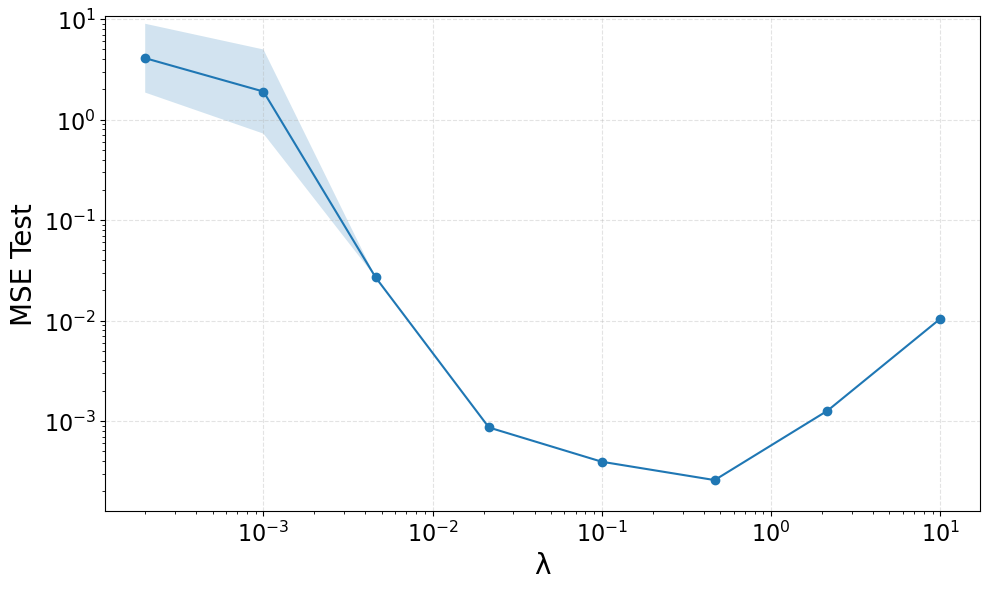

In [17]:
# ---- plotting config ----
metric = METRIC.strip()
metric_pretty = _pretty_metric(metric)
y_col = f"{metric}_mean"
lo_col = f"{metric}_ci_lo"
hi_col = f"{metric}_ci_hi"

# aggregated CI cols are named e.g. mse_test_ci_lo/hi in the original script
# because we used _split_ci on the *_ci columns.
lo_col = f"{metric}_ci_lo"
hi_col = f"{metric}_ci_hi"
# But in aggregate_by_hparams we created columns like: mse_test_ci_lo? actually we created mse_test_ci_lo by splitting mse_test_ci.
# Those columns are: 'mse_test_ci_lo' etc. Here we follow that convention:
lo_col = f"{metric}_ci_lo"
hi_col = f"{metric}_ci_hi"
# If you kept the original naming from your script: it's '{metric}_ci_lo'/'{metric}_ci_hi'. We'll sanity check:
if lo_col not in df_agg.columns:
    lo_col = f"{metric}_ci_lo"
if hi_col not in df_agg.columns:
    hi_col = f"{metric}_ci_hi"

if y_col not in df_agg.columns:
    raise ValueError(f"Metric mean column not found: {y_col}")
if lo_col not in df_agg.columns or hi_col not in df_agg.columns:
    raise ValueError(f"CI columns not found for metric={metric}. Expected {lo_col}/{hi_col}.")

yscale = "linear" if metric.startswith("time") else "log"

# apply filters
sub = df_agg.copy()

# determine targets if not provided
target_tol = TARGET_TOL if TARGET_TOL is not None else (sub["tol"].iloc[0] if "tol" in sub.columns else None)
target_reg = TARGET_REG if TARGET_REG is not None else (sub["penalty_lambda_reg"].iloc[0] if "penalty_lambda_reg" in sub.columns else None)

if X_AXIS == "reg" and "tol" in sub.columns and target_tol is not None:
    sub = sub[sub["tol"] == target_tol]
elif X_AXIS == "tol" and "penalty_lambda_reg" in sub.columns and target_reg is not None:
    sub = sub[sub["penalty_lambda_reg"] == target_reg]
elif X_AXIS == "width":
    if "penalty_lambda_reg" in sub.columns and target_reg is not None:
        sub = sub[sub["penalty_lambda_reg"] == target_reg]
    if "tol" in sub.columns and target_tol is not None:
        sub = sub[sub["tol"] == target_tol]

if LAYER_WIDTH_FILTER is not None and X_AXIS != "width":
    sub = sub[sub["layer_widths"] == tuple(LAYER_WIDTH_FILTER)]

sub = sub[sub["n_runs"] >= MIN_RUNS]

if sub.empty:
    raise ValueError("No rows left after filtering. Adjust TARGET_TOL/TARGET_REG/LAYER_WIDTH_FILTER/MIN_RUNS.")

# ---- plot ----
if X_AXIS == "reg":
    x_col = "penalty_lambda_reg"
    xlabel = "λ"
    xscale = "log"
    title_suffix = f"tol={target_tol}"
elif X_AXIS == "tol":
    x_col = "tol"
    xlabel = "tol"
    xscale = "log"
    title_suffix = f"λ={target_reg}"
else:
    x_col = "layer_widths"
    xlabel = "Layer width"
    xscale = "linear"
    title_suffix = f"λ={target_reg}, tol={target_tol}"

fig, ax = plt.subplots(figsize=(10, 6))

def _plot_one(ax, x, y, lo, hi, label=None):
    if Graphs is not None and hasattr(Graphs, "plot_reg_curve_ci"):
        Graphs.plot_reg_curve_ci(
            x,
            y,
            lo,
            hi,
            title=None,
            xlabel=xlabel,
            ylabel=metric_pretty,
            xscale=xscale,
            yscale=yscale,
            add_errorbars=False,
            show_points=SHOW_POINTS,
            title_on=False,
            preserve_label_case=True,
            inset=False,
            ax=ax,
            label_fontsize=DEFAULT_LABEL_FONT_SIZE,
            title_fontsize=DEFAULT_LABEL_FONT_SIZE,
            tick_fontsize=DEFAULT_TICK_FONT_SIZE,
        )
    else:
        plot_reg_curve_ci(
            x,
            y,
            lo,
            hi,
            title=None,
            xlabel=xlabel,
            ylabel=metric_pretty,
            xscale=xscale,
            yscale=yscale,
            show_points=SHOW_POINTS,
            ax=ax,
        )

if X_AXIS == "width":
    g = sub.sort_values("layer_widths").copy()
    g[lo_col] = g[lo_col].fillna(g[y_col])
    g[hi_col] = g[hi_col].fillna(g[y_col])
    g = g.dropna(subset=[y_col])
    x_vals = np.arange(len(g))
    _plot_one(ax, x_vals, g[y_col].to_numpy(), g[lo_col].to_numpy(), g[hi_col].to_numpy())
    ax.set_xticks(x_vals)
    ax.set_xticklabels([_format_layer_width(lw) for lw in g["layer_widths"]], rotation=20, ha="right")
else:
    # multiple widths -> plot each width separately
    if "layer_widths" in sub.columns and sub["layer_widths"].nunique() > 1:
        for lw, g in sub.groupby("layer_widths"):
            g = g.sort_values(x_col).copy()
            # fill CI NaNs with mean to keep points
            g[lo_col] = g[lo_col].fillna(g[y_col])
            g[hi_col] = g[hi_col].fillna(g[y_col])
            g = g.dropna(subset=[y_col])
            if g.empty:
                continue
            _plot_one(ax, g[x_col].to_numpy(), g[y_col].to_numpy(), g[lo_col].to_numpy(), g[hi_col].to_numpy(), label=str(lw))
        ax.legend(title="layer_widths", fontsize=10)
    else:
        g = sub.sort_values(x_col).copy()
        g[lo_col] = g[lo_col].fillna(g[y_col])
        g[hi_col] = g[hi_col].fillna(g[y_col])
        g = g.dropna(subset=[y_col])
        _plot_one(ax, g[x_col].to_numpy(), g[y_col].to_numpy(), g[lo_col].to_numpy(), g[hi_col].to_numpy())

if not NO_TITLE:
    ax.set_title(f"{metric_pretty} vs {xlabel} ({title_suffix})")
fig.tight_layout()

if SAVE_PLOTS:
    OUTDIR.mkdir(parents=True, exist_ok=True)
    outname = f"{results_dir.name}_line_{metric}_{X_AXIS}.png"
    outpath = OUTDIR / outname
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    print(f"Saved: {outpath}")

plt.show()


## Export

In [18]:
# Optional: export aggregated table
csv_path = Path("results") / "aggregated_sweep.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
df_agg.to_csv(csv_path, index=False)
print(f"Wrote {csv_path.resolve()}")


Wrote /Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/analysis/synthetic/results/aggregated_sweep.csv
